In [99]:
import os
import sys
from tqdm import tqdm
import numpy as np
import torch
import yaml
import random
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.autograd import Variable
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

In [100]:
torch.cuda.is_available()

True

In [101]:
base_url = os.getcwd()
sys.path.append(base_url + '/Util')

In [102]:
# from model import *
import utils
# from models import *
# from data_preprocess import *
from visualization import *

In [103]:
class Extractor(nn.Module):
    def __init__(self):
        super(Extractor, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=(1, 9))
        # self.bn1 = nn.BatchNorm2d(64)
        self.selu1 = nn.SELU()
        self.maxpool1 = nn.MaxPool2d(kernel_size=(1, 2), stride=2, return_indices=False)

        self.conv2 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=(1, 9))
        # self.bn2 = nn.BatchNorm2d(50)
        self.selu2 = nn.SELU()
        self.maxpool2 = nn.MaxPool2d(kernel_size=(1, 2), stride=2, return_indices=False)
        
        self.conv3 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=(1, 9))
        self.selu3 = nn.SELU()
        
        self.conv4_drop = nn.Dropout()
        
        self.fc1 = nn.Linear(256*18, 256)
        self.bn3 = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256, 128)
        self.bn4 = nn.BatchNorm1d(128)

    def forward(self, x):
        x = self.conv1(x)
        x = self.selu1(x)
        x = self.maxpool1(x)
        # print(x.shape)
        x = self.conv2(x)
        x = self.selu2(x)
        x = self.maxpool2(x)
        # print(x.shape)
        x = self.conv3(x)
        x = self.selu3(x)
        
        x = self.conv4_drop(x)
        # print(x.shape)
        
        x = x.view(-1, 256*18)
        x = self.fc1(x)
        x = self.bn3(x)
        x = self.fc2(x)
        x = self.bn4(x)
        return x

class Classifier(nn.Module):

    def __init__(self, num_classes=10):
        super(Classifier, self).__init__()
        self.fc3 = nn.Linear(128, num_classes)

    def forward(self, input):
        logits = self.fc3(input)

        return logits

In [104]:
def calculate_window(dataframe, data, data_gt, win_size, step_size, start_col, end_col, gt_start_col, gt_end_col, axis_no):
    len_df = dataframe.shape[0]
    narray = dataframe.to_numpy()
    for i in range(0, len_df, step_size):
        window = narray[i:i+win_size, start_col:end_col]

        if window.shape[0] != win_size:
            continue
        else:
            reshaped_window = window.reshape(1, win_size, 1, axis_no)
            gt = np.bincount(narray[i:i+win_size,gt_start_col:gt_end_col].astype(int).ravel()).argmax()
            
            data.append(reshaped_window)
            data_gt.append(gt)


class modified_data_loader(Dataset):
    def __init__(self, samples, labels, transform=None):
        self.samples = samples
        self.labels = labels
        self.transform = transform

    def __getitem__(self, index):
        return self.samples[index], self.labels[index]

    def __len__(self):
        return len(self.samples)
    
    
def modified_load_train_valid_test(train_x, train_y, valid_x, valid_y, test_x, test_y, batch_size=64, drop_last=True):
    train_x_swap = np.swapaxes(train_x,1,3)
    valid_x_swap = np.swapaxes(valid_x,1,3)
    test_x_swap = np.swapaxes(test_x,1,3)
    
    train_set = modified_data_loader(train_x_swap, train_y)
    valid_set = modified_data_loader(valid_x_swap, valid_y)
    test_set = modified_data_loader(test_x_swap, test_y)
    
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, drop_last=drop_last)
    valid_loader = DataLoader(valid_set, batch_size=batch_size, shuffle=True, drop_last=drop_last)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=True, drop_last=drop_last)
    return train_loader, valid_loader, test_loader

# Intended Task

In [105]:
TASKS = ["Cross-Position", "Cross-Person", "Cross-Device"]
task = None
while True:
    print("1. Cross-Position\n2. Cross-Person\n3. Cross-Device")
    user_input = input("Please enter your task: ")
    if user_input == "1":
        task = "Cross-Position"
    elif user_input == "2":
        task = "Cross-Person"
    elif user_input == "3":
        task = "Cross-Device"
    if task in TASKS:
        break
    else:
        print("Invalid task. Please choose a valid task.")
print(f"Chosen task: {task}")

1. Cross-Position
2. Cross-Person
3. Cross-Device
Please enter your task: 1
Chosen task: Cross-Position


# Dataset Selection

In [106]:
DATASETS = ["OPP", "DSADS", "PAMAP", "WISDM", "HHAR"]
dataset = None
if task == 'Cross-Position':
    while True:
        print("1. OPP\n2. DSADS\n3. PAMAP\n")
        user_input = input("Please enter your dataset: ")
        if user_input == "1":
            dataset = "OPP"
        elif user_input == "2":
            dataset = "DSADS"
        elif user_input == "3":
            dataset = "PAMAP"
        if dataset in DATASETS:
            break
        else:
            print("Invalid dataset. Please choose a valid dataset.")
elif task == 'Cross-Person':
    while True:
        print("1. OPP\n2. DSADS\n3. PAMAP\n4. WISDM\n")
        user_input = input("Please enter your dataset: ")
        if user_input == "1":
            dataset = "OPP"
        elif user_input == "2":
            dataset = "DSADS"
        elif user_input == "3":
            dataset = "PAMAP"
        elif user_input == "4":
            dataset = "WISDM"
        if dataset in DATASETS:
            break
        else:
            print("Invalid dataset. Please choose a valid dataset.")
print(f"Chosen dataset: {dataset}")

1. OPP
2. DSADS
3. PAMAP

Please enter your dataset: 2
Chosen dataset: DSADS


# Reproduciblitiy (Must Change Before Each Experiment)

In [107]:
os.environ["CUBLAS_WORKSPACE_CONFIG"]=":4096:8"

def set_seed(seed=42, loader=None):
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    try:
        loader.sampler.generator.manual_seed(seed)
    except AttributeError:
        pass

seeds = [0, 1, 42, 123, 1234]
seed = seeds[0] # Change this
set_seed(seed=seed)

In [108]:
# All of these have to taken input from shell script
win_size = 128
overlap = 0.1

if task == "Cross-Position":
    if dataset == "DSADS":
        domains = {0:"TORSO", 1:"RA", 2:"LA", 3:"RL", 4:"LL"}
        sources = [0, 1, 2, 3]
        nsources = len(sources)
        target = 4
        activities = [ "standing", "lying-back", "ascending", "walking-parking-lot", "treadmill-running", "stepper-exercise", "cross-trainer-exercise", "rowing", "jumping",  "playing-basketball"]
        activity_num = len(activities)
        item = ["train","valid","test"]
        person_list = ["User1","User2","User3","User4", "User5","User6","User7","User8"]
        position_array = ["TORSO","RA","LA","RL","LL"]
    elif dataset == "OPP":
        domains = {0:"BACK", 1:"RUA", 2:"RLA", 3:"LUA", 4:"LLA"}
        sources = [1, 2, 3, 4]
        nsources = len(sources)
        target = 0
        activities = ['Sitting','Standing','Walking','Running']
        activity_num = len(activities)
        item = ["train","valid","test"]
        person_list = ["U1","U2","U3","U4"]
        position_array = ["BACK", "RUA", "RLA", "LUA","LLA"]
    elif dataset == "PAMAP":
        domains = {0:"Wrist", 1:"Chest", 2:"Ankle"}
        sources = [0, 2]
        nsources = len(sources)
        target = 1
        activities = ['ascending', 'lying', 'sitting', 'standing', 'walking', 'descending', 'vacuum', 'ironing', 'running', 'cycling', 'rope_jumping']
        activity_num = len(activities)
        item = ["train","valid","test"]
        person_list = ["U1","U2","U3","U4","U5","U6","U7","U8"]
        position_array = ['Wrist', 'Chest', 'Ankle']
        
elif task == "Cross-Person":
    if dataset == "DSADS":
        domains = {0:"User1", 1:"User2", 2:"User3", 3:"User4", 4:"User5", 5:"User6", 6:"User7", 7:"User8"}
        sources = [4, 5, 6, 7]
        target = [0, 1, 2, 3]
        nsources = len(sources)
        position_list = ["TORSO", "RA", "LA", "RL", "LL"]
        activities = [ "standing", "lying-back", "ascending", "walking-parking-lot", "treadmill-running", "stepper-exercise", "cross-trainer-exercise", "rowing", "jumping",  "playing-basketball"]
        activity_num = len(activities)
        item = ["train","valid","test"]
        person_array = ["User1","User2","User3","User4","User5","User6","User7","User8"]
    elif dataset == "OPP":
        domains = {0:"U1", 1:"U2", 2:"U3", 3:"U4"}
        sources = [0, 1]
        target = [2, 3]
        nsources = len(sources)
        position_list = ["BACK", "RUA", "RLA", "LUA","LLA"]
        activities = ['Sitting','Standing','Walking','Running']
        activity_num = len(activities)
        item = ["train","valid","test"]
        person_array = ["U1","U2","U3","U4"]
    elif dataset == "PAMAP":
        domains = {0:'U1', 1:'U2', 2:'U3', 3:'U4', 4:'U5', 5:'U6', 6:'U7', 7:'U8'}
        sources = [0, 1, 2, 3]
        nsources = len(sources)
        target = [4, 5, 6, 7]
        activities = ['ascending', 'lying', 'sitting', 'standing', 'walking', 'descending', 'vacuum', 'ironing', 'running', 'cycling', 'rope_jumping']
        activity_num = len(activities)
        item = ["train","valid","test"]
        position_list = ['Wrist', 'Chest', 'Ankle']
        person_array = ["U1","U2","U3","U4","U5","U6","U7","U8"]
elif task == "Cross-Device":
    pass

print(activity_num)

10


In [109]:
step_size=int(win_size*(1-overlap))
gpu_id= 0
DEVICE = torch.device('cuda:'+str(gpu_id) if torch.cuda.is_available() else 'cpu')

In [110]:
if dataset == "DSADS":
    AXIS = 3
    FROM = 0
    TO = FROM+3
    START = 4
    END = 5
elif dataset == "OPP":
    AXIS = 3
    FROM = 0
    TO = FROM+3
    START = 3
    END = 4
elif dataset == "PAMAP":
    AXIS = 3
    FROM = 0
    TO = FROM+3
    START = 4
    END = 5

In [111]:
if task == "Cross-Position":
    if dataset == "DSADS":
        folder_name = str(activity_num)+ "_Activity"+"_Window_"+str(win_size)+ "_Overlap_"+str(overlap)
        dataset_path = base_url + "/Dataset_Preprocessed/DSADS/Data Files/"+folder_name+"/"
        save_path = base_url + "/Output/DSADS-Cross-Position-Heterogeneity/"+folder_name+"/Target-Position-" + position_array[target] + '/seed' + str(seed) + "/"
        main_folder = "DSADS-AllPerson-DifferentPosition"
    elif dataset == "OPP":
        folder_name = str(activity_num)+ "_Activity"+"_Window_"+str(win_size)+ "_Overlap_"+str(overlap)
        dataset_path = base_url + "/Dataset_Preprocessed/OPPORTUNITY/Data Files/"+folder_name+"/"
        save_path = base_url + "/Output/OPP-Cross-Position-Heterogeneity/"+folder_name+"/Target-Position-" + position_array[target] + '/seed' + str(seed) + "/"
        main_folder = "OPP-AllPerson-DifferentPosition"
    elif dataset == "PAMAP":
        folder_name = str(activity_num)+ "_Activity"+"_Window_"+str(win_size)+ "_Overlap_"+str(overlap)
        dataset_path = base_url + "/Dataset_Preprocessed/PAMAP/Data Files/"+folder_name+"/"
        save_path = base_url + "/Output/PAMAP-Cross-Position-Heterogeneity/"+folder_name+"/Target-Position-" + position_array[target] + '/seed' + str(seed) + "/"
        main_folder = "PAMAP-AllPerson-DifferentPosition"
        
elif task == "Cross-Person":
    target_string = "_".join([domains[i] for i in target])
    if dataset == "DSADS":
        folder_name = str(activity_num)+ "_Activity"+"_Window_"+str(win_size)+ "_Overlap_"+str(overlap)
        dataset_path = base_url + "/Dataset_Preprocessed/DSADS/Data Files/"+folder_name+"/"
        save_path = base_url + "/Output/DSADS-Cross-Person-Heterogeneity/"+folder_name+"/Target-" + target_string + '/seed' + str(seed) + "/"
        main_folder = "DSADS-SamePosition-DifferentPerson"
    elif dataset == "OPP":
        folder_name = str(activity_num)+ "_Activity"+"_Window_"+str(win_size)+ "_Overlap_"+str(overlap)
        dataset_path = base_url + "/Dataset_Preprocessed/OPPORTUNITY/Data Files/"+folder_name+"/"
        save_path = base_url + "/Output/OPP-Cross-Person-Heterogeneity/"+folder_name+"/Target-" + target_string + '/seed' + str(seed) + "/"
        main_folder = "OPP-SamePosition-DifferentPerson"
    elif dataset == "PAMAP":
        folder_name = str(activity_num)+ "_Activity"+"_Window_"+str(win_size)+ "_Overlap_"+str(overlap)
        dataset_path = base_url + "/Dataset_Preprocessed/PAMAP/Data Files/"+folder_name+"/"
        save_path = base_url + "/Output/PAMAP-Cross-Person-Heterogeneity/"+folder_name+"/Target-" + target_string + '/seed' + str(seed) + "/"
        main_folder = "PAMAP-AllPerson-DifferentPerson"

if not os.path.exists(save_path):
    os.makedirs(save_path)

In [112]:
# All of these have to taken input from shell script
# the target and source domain position
LEARNING_RATE = 0.01
WEIGHT_DECAY = 0.0005
MOMENTUM = 0.9
# BATCH_SIZE = [200, 56]
BATCH_SIZE = 32
EPOCHS = 20
THETA1 = 0.33
THETA2 = 0.34
THETA3 = 0.33
PLOT_ITER = 10

In [113]:
s_train = []
t_train = []

s_gt_train = []
t_gt_train = []

#===================================================#

s_valid = []
t_valid = []

s_gt_valid = []
t_gt_valid = []

#===================================================#

s_test = []
t_test = []

s_gt_test = []
t_gt_test = []

In [114]:
# sources can be [0, 1, 3, 4], and target = 2
if task == 'Cross-Position':
    print('Source')
    # Create an empty DataFrame to hold the aggregated data for this source position
    df_aggregated_train = pd.DataFrame()
    df_aggregated_valid = pd.DataFrame()
    df_aggregated_test = pd.DataFrame()
    for i in range(len(sources)):
        # Combine data from all users for the current source position
        for person in person_list:
            for split_index in range(0, 3):
                file_name = person + "_" + position_array[sources[i]] + '_' + item[split_index]
                print(f"Processing: {file_name}")
                df = pd.read_csv(dataset_path + file_name + '.csv', sep=",")
                
                # Aggregate data into the corresponding split DataFrame
                if split_index == 0:
                    df_aggregated_train = pd.concat([df_aggregated_train, df], ignore_index=True)
                elif split_index == 1:
                    df_aggregated_valid = pd.concat([df_aggregated_valid, df], ignore_index=True)
                elif split_index == 2:
                    df_aggregated_test = pd.concat([df_aggregated_test, df], ignore_index=True)
        
        # Pass the aggregated data to calculate_window
    calculate_window(df_aggregated_train, s_train, s_gt_train, win_size, step_size, FROM, TO, START, END, AXIS)
    calculate_window(df_aggregated_valid, s_valid, s_gt_valid, win_size, step_size, FROM, TO, START, END, AXIS)
    calculate_window(df_aggregated_test, s_test, s_gt_test, win_size, step_size, FROM, TO, START, END, AXIS)

    # For the target position, similarly aggregate data across all users
    print('Target')
    df_aggregated_train_target = pd.DataFrame()
    df_aggregated_valid_target = pd.DataFrame()
    df_aggregated_test_target = pd.DataFrame()
    for person in person_list:
        for split_index in range(0, 3):
            file_name = person + "_" + position_array[target] + '_' + item[split_index]
            print(f"Processing: {file_name}")
            df = pd.read_csv(dataset_path + file_name + '.csv', sep=",")
            
            if split_index == 0:
                df_aggregated_train_target = pd.concat([df_aggregated_train_target, df], ignore_index=True)
            elif split_index == 1:
                df_aggregated_valid_target = pd.concat([df_aggregated_valid_target, df], ignore_index=True)
            elif split_index == 2:
                df_aggregated_test_target = pd.concat([df_aggregated_test_target, df], ignore_index=True)

    calculate_window(df_aggregated_train_target, t_train, t_gt_train, win_size, step_size, FROM, TO, START, END, AXIS)
    calculate_window(df_aggregated_valid_target, t_valid, t_gt_valid, win_size, step_size, FROM, TO, START, END, AXIS)
    calculate_window(df_aggregated_test_target, t_test, t_gt_test, win_size, step_size, FROM, TO, START, END, AXIS)
    
elif task == 'Cross-Person':
    for i in range(len(sources)):
        # Create an empty DataFrame to hold the aggregated data for this source position
        df_aggregated_train = pd.DataFrame()
        df_aggregated_valid = pd.DataFrame()
        df_aggregated_test = pd.DataFrame()
        
        for position in position_list:
            for split_index in range(0, 3):
                file_name = person_array[sources[i]] + "_" + position + '_' + item[split_index]
                print(f"Processing: {file_name}")
                df = pd.read_csv(dataset_path + file_name + '.csv', sep=",")
                
                # Aggregate data into the corresponding split DataFrame
                if split_index == 0:
                    df_aggregated_train = pd.concat([df_aggregated_train, df], ignore_index=True)
                elif split_index == 1:
                    df_aggregated_valid = pd.concat([df_aggregated_valid, df], ignore_index=True)
                elif split_index == 2:
                    df_aggregated_test = pd.concat([df_aggregated_test, df], ignore_index=True)
        
        # Pass the aggregated data to calculate_window
        calculate_window(df_aggregated_train, s_train[i], s_gt_train[i], win_size, step_size, FROM, TO, START, END, AXIS)
        calculate_window(df_aggregated_valid, s_valid[i], s_gt_valid[i], win_size, step_size, FROM, TO, START, END, AXIS)
        calculate_window(df_aggregated_test, s_test[i], s_gt_test[i], win_size, step_size, FROM, TO, START, END, AXIS)

    
    # For the target position, similarly aggregate data across all users
    df_aggregated_train_target = pd.DataFrame()
    df_aggregated_valid_target = pd.DataFrame()
    df_aggregated_test_target = pd.DataFrame()
    for i in range(len(target)):
        for position in position_list:
            for split_index in range(0, 3):
                file_name = person_array[target[i]] + "_" + position + '_' + item[split_index]
                print(f"Processing: {file_name}")
                df = pd.read_csv(dataset_path + file_name + '.csv', sep=",")

                if split_index == 0:
                    df_aggregated_train_target = pd.concat([df_aggregated_train_target, df], ignore_index=True)
                elif split_index == 1:
                    df_aggregated_valid_target = pd.concat([df_aggregated_valid_target, df], ignore_index=True)
                elif split_index == 2:
                    df_aggregated_test_target = pd.concat([df_aggregated_test_target, df], ignore_index=True)

    calculate_window(df_aggregated_train_target, t_train, t_gt_train, win_size, step_size, FROM, TO, START, END, AXIS)
    calculate_window(df_aggregated_valid_target, t_valid, t_gt_valid, win_size, step_size, FROM, TO, START, END, AXIS)
    calculate_window(df_aggregated_test_target, t_test, t_gt_test, win_size, step_size, FROM, TO, START, END, AXIS)

elif task == "Cross-Device":
    pass

Source
Processing: User1_TORSO_train
Processing: User1_TORSO_valid
Processing: User1_TORSO_test
Processing: User2_TORSO_train
Processing: User2_TORSO_valid
Processing: User2_TORSO_test
Processing: User3_TORSO_train
Processing: User3_TORSO_valid
Processing: User3_TORSO_test
Processing: User4_TORSO_train
Processing: User4_TORSO_valid
Processing: User4_TORSO_test
Processing: User5_TORSO_train
Processing: User5_TORSO_valid
Processing: User5_TORSO_test
Processing: User6_TORSO_train
Processing: User6_TORSO_valid
Processing: User6_TORSO_test
Processing: User7_TORSO_train
Processing: User7_TORSO_valid
Processing: User7_TORSO_test
Processing: User8_TORSO_train
Processing: User8_TORSO_valid
Processing: User8_TORSO_test
Processing: User1_RA_train
Processing: User1_RA_valid
Processing: User1_RA_test
Processing: User2_RA_train
Processing: User2_RA_valid
Processing: User2_RA_test
Processing: User3_RA_train
Processing: User3_RA_valid
Processing: User3_RA_test
Processing: User4_RA_train
Processing: Us

In [115]:
# Converting data list to numpy data

# Source
s_train = np.concatenate(s_train, axis=0).astype(np.float32)
s_gt_train = np.array(s_gt_train).astype(np.float32)
s_valid = np.concatenate(s_valid, axis=0).astype(np.float32)
s_gt_valid = np.array(s_gt_valid).astype(np.float32)
s_test = np.concatenate(s_test, axis=0).astype(np.float32)
s_gt_test = np.array(s_gt_test).astype(np.float32)

#======================================================================

# Target:
t_train = np.concatenate(t_train, axis=0).astype(np.float32)
t_gt_train = np.array(t_gt_train).astype(np.float32)
t_valid = np.concatenate(t_valid, axis=0).astype(np.float32)
t_gt_valid = np.array(t_gt_valid).astype(np.float32)
t_test = np.concatenate(t_test, axis=0).astype(np.float32)
t_gt_test = np.array(t_gt_test).astype(np.float32)

In [116]:
print(s_train.shape)
print(t_train.shape)

(12521, 128, 1, 3)
(3130, 128, 1, 3)


In [117]:
drop_last = True
S_train, S_valid, S_test = modified_load_train_valid_test(s_train, s_gt_train, s_valid, s_gt_valid, s_test, s_gt_test, BATCH_SIZE, drop_last)
T_train, T_valid, T_test = modified_load_train_valid_test(t_train, t_gt_train, t_valid, t_gt_valid, t_test, t_gt_test, BATCH_SIZE, drop_last)

In [118]:
def test(common_net, src_net, source_dataloader, target_dataloader, epoch, DEVICE, test_hist):

    common_net.eval()
    src_net.eval()
    
    all_preds = []
    all_labels = []

    source_correct = 0
    target_correct = 0
    target_f1 = 0

    for batch_idx, (sdata, slabel) in enumerate(source_dataloader):
        sdata, slabel = sdata.to(DEVICE).float(), slabel.to(DEVICE).long()
        output1 = src_net(common_net(sdata))
        pred1 = output1.data.max(1, keepdim = True)[1]
        source_correct += pred1.eq(slabel.data.view_as(pred1)).cpu().sum()

    for batch_idx, (tdata, tlabel) in enumerate(target_dataloader):
        tdata, tlabel = tdata.to(DEVICE).float(), tlabel.to(DEVICE).long()
        output2 = src_net(common_net(tdata))
        pred2 = output2.data.max(1, keepdim=True)[1]
        target_correct += pred2.eq(tlabel.data.view_as(pred2)).cpu().sum()
        
        all_preds.extend(pred2.cpu().numpy())
        all_labels.extend(tlabel.cpu().numpy())

    source_accuracy = 100. * source_correct / len(source_dataloader.dataset)
    target_accuracy = 100. * target_correct / len(target_dataloader.dataset)
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    micro_f1 = f1_score(all_labels, all_preds, average='micro')

    print('\nSource Accuracy: {}/{} ({:.4f}%)\nTarget Accuracy: {}/{} ({:.4f}%)\nTarget micro-f1: {}'.format(
        source_correct, len(source_dataloader.dataset), source_accuracy,
        target_correct, len(target_dataloader.dataset), target_accuracy,
        micro_f1
    ))
    test_hist['Source Accuracy'].append(source_accuracy.cpu().item())
    test_hist['Target Accuracy'].append(target_accuracy.cpu().item())
    test_hist['Micro-F1'].append(float(micro_f1))
    
    plt.figure(figsize=(20, 20))
    plot_cm = confusion_matrix(all_labels, all_preds)
    plot_confusion_matrix(plot_cm, classes=activities, title="confusion_matrix", plot_save_path=save_path, show=True)
    

def train(common_net, src_net, tgt_net, optimizer, criterion, epoch,
          source_dataloader, target_dataloader, DEVICE, train_hist):
    common_net.train()
    src_net.train()
    tgt_net.train()

    source_iter = iter(source_dataloader)
    target_iter = iter(target_dataloader)

    for batch_idx in range(min(len(source_dataloader), len(target_dataloader))):
        # get data
        sdata, slabel = next(source_iter)
        tdata, _ = next(target_iter)

        sdata, slabel = sdata.to(DEVICE).float(), slabel.to(DEVICE).long()
        tdata = tdata.to(DEVICE).float()
        
        sdata, slabel = Variable(sdata), Variable(slabel)
        tdata = Variable(tdata)

        optimizer.zero_grad()

        sdata = sdata.expand(sdata.shape[0], 3, 1, 128)
        input = torch.cat((sdata, tdata), 0)
        common_feature = common_net(input)

        src_feature, tgt_feature = torch.split(common_feature, int(BATCH_SIZE))

        src_output = src_net(src_feature)
        tgt_output = tgt_net(tgt_feature)

        class_loss = criterion(src_output, slabel)

        mmd_loss = utils.mmd_loss(src_feature, tgt_feature) * THETA1 + \
                   utils.mmd_loss(src_output, tgt_output) * THETA2

        loss = class_loss + mmd_loss
        loss.backward()
        optimizer.step()
        step = epoch * len(target_dataloader) + batch_idx


        if (batch_idx + 1) % PLOT_ITER == 0:
            print('[{}/{} ({:.0f}%)]\tLoss: {:.6f}\tClass Loss: {:.6f}\tMMD Loss: {:.6f}'.format(
                batch_idx * len(tdata), len(target_dataloader.dataset),
                100. * batch_idx / len(target_dataloader), loss.item(), class_loss.item(),
                mmd_loss.item()
            ))
            train_hist['Total_loss'].append(loss.cpu().item())
            train_hist['Class_loss'].append(class_loss.cpu().item())
            train_hist['MMD_loss'].append(mmd_loss.cpu().item())


Epoch: 1
[288/3130 (9%)]	Loss: 2.428051	Class Loss: 1.705763	MMD Loss: 0.722288
[608/3130 (20%)]	Loss: 2.314874	Class Loss: 1.707092	MMD Loss: 0.607782
[928/3130 (30%)]	Loss: 2.530395	Class Loss: 1.762966	MMD Loss: 0.767428
[1248/3130 (40%)]	Loss: 2.247678	Class Loss: 1.664863	MMD Loss: 0.582815
[1568/3130 (51%)]	Loss: 2.243029	Class Loss: 1.646675	MMD Loss: 0.596354
[1888/3130 (61%)]	Loss: 2.165183	Class Loss: 1.572447	MMD Loss: 0.592736
[2208/3130 (71%)]	Loss: 2.081673	Class Loss: 1.528901	MMD Loss: 0.552772
[2528/3130 (81%)]	Loss: 2.179146	Class Loss: 1.467014	MMD Loss: 0.712132
[2848/3130 (92%)]	Loss: 2.191985	Class Loss: 1.425425	MMD Loss: 0.766560

Source Accuracy: 2305/4171 (55.2625%)
Target Accuracy: 379/1042 (36.3724%)
Target micro-f1: 0.3701171875


<Figure size 2000x2000 with 0 Axes>

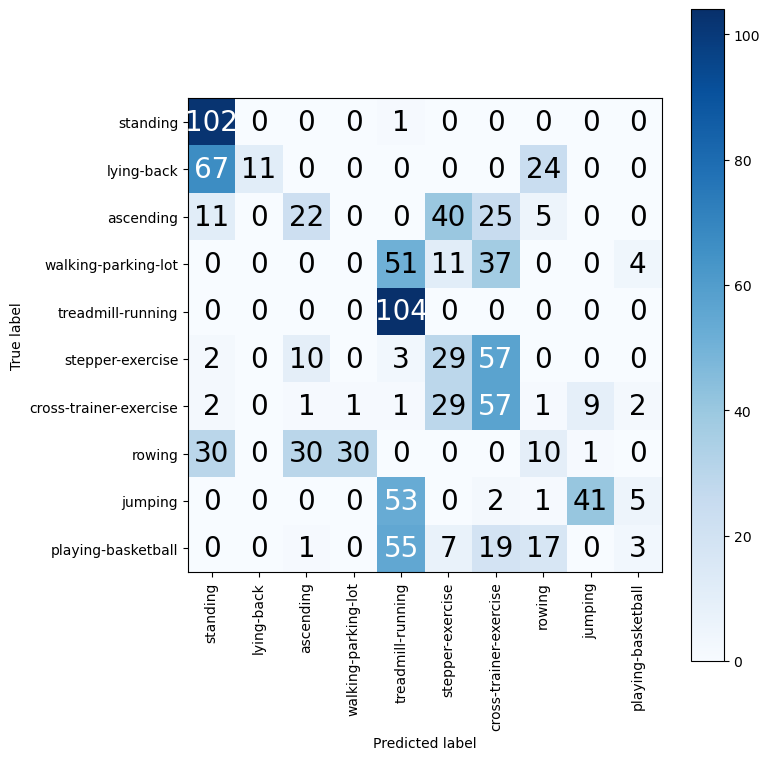

Epoch: 2
[288/3130 (9%)]	Loss: 1.869823	Class Loss: 1.234728	MMD Loss: 0.635095
[608/3130 (20%)]	Loss: 1.623625	Class Loss: 1.000568	MMD Loss: 0.623057
[928/3130 (30%)]	Loss: 1.673695	Class Loss: 1.076335	MMD Loss: 0.597359
[1248/3130 (40%)]	Loss: 1.432069	Class Loss: 0.775616	MMD Loss: 0.656452
[1568/3130 (51%)]	Loss: 1.331994	Class Loss: 0.722625	MMD Loss: 0.609369
[1888/3130 (61%)]	Loss: 1.597671	Class Loss: 0.994830	MMD Loss: 0.602841
[2208/3130 (71%)]	Loss: 1.369907	Class Loss: 0.606353	MMD Loss: 0.763555
[2528/3130 (81%)]	Loss: 1.655701	Class Loss: 1.015530	MMD Loss: 0.640171
[2848/3130 (92%)]	Loss: 1.500627	Class Loss: 0.795816	MMD Loss: 0.704811

Source Accuracy: 2624/4171 (62.9106%)
Target Accuracy: 458/1042 (43.9539%)
Target micro-f1: 0.447265625


<Figure size 2000x2000 with 0 Axes>

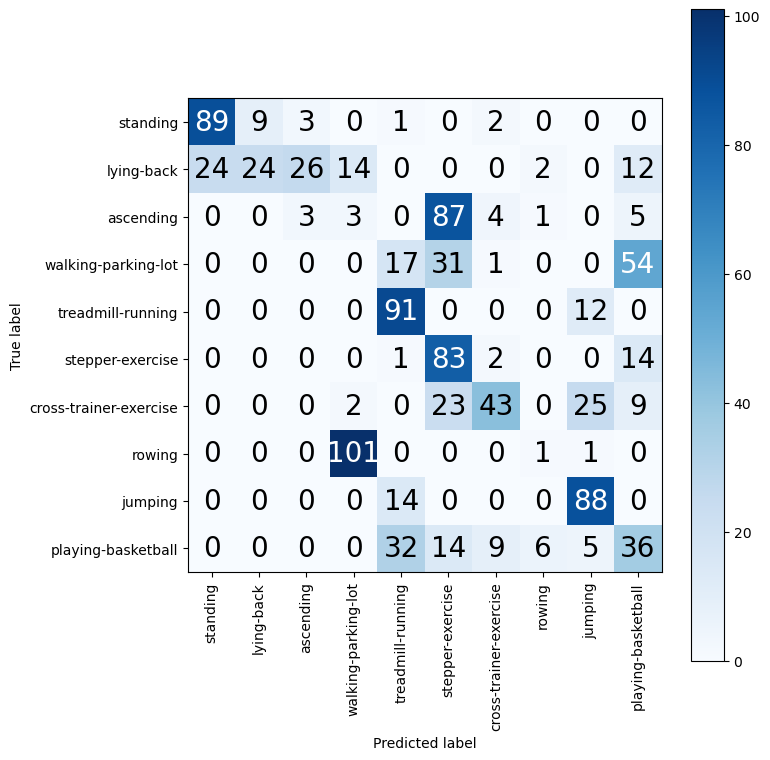

Epoch: 3
[288/3130 (9%)]	Loss: 1.572258	Class Loss: 0.961030	MMD Loss: 0.611227
[608/3130 (20%)]	Loss: 1.574944	Class Loss: 0.937272	MMD Loss: 0.637672
[928/3130 (30%)]	Loss: 1.683613	Class Loss: 0.950996	MMD Loss: 0.732617
[1248/3130 (40%)]	Loss: 1.538931	Class Loss: 0.792766	MMD Loss: 0.746165
[1568/3130 (51%)]	Loss: 1.215259	Class Loss: 0.525144	MMD Loss: 0.690115
[1888/3130 (61%)]	Loss: 1.430908	Class Loss: 0.768252	MMD Loss: 0.662656
[2208/3130 (71%)]	Loss: 1.663689	Class Loss: 0.970454	MMD Loss: 0.693235
[2528/3130 (81%)]	Loss: 1.522044	Class Loss: 0.874182	MMD Loss: 0.647862
[2848/3130 (92%)]	Loss: 1.445263	Class Loss: 0.867003	MMD Loss: 0.578259

Source Accuracy: 2979/4171 (71.4217%)
Target Accuracy: 444/1042 (42.6104%)
Target micro-f1: 0.43359375


<Figure size 2000x2000 with 0 Axes>

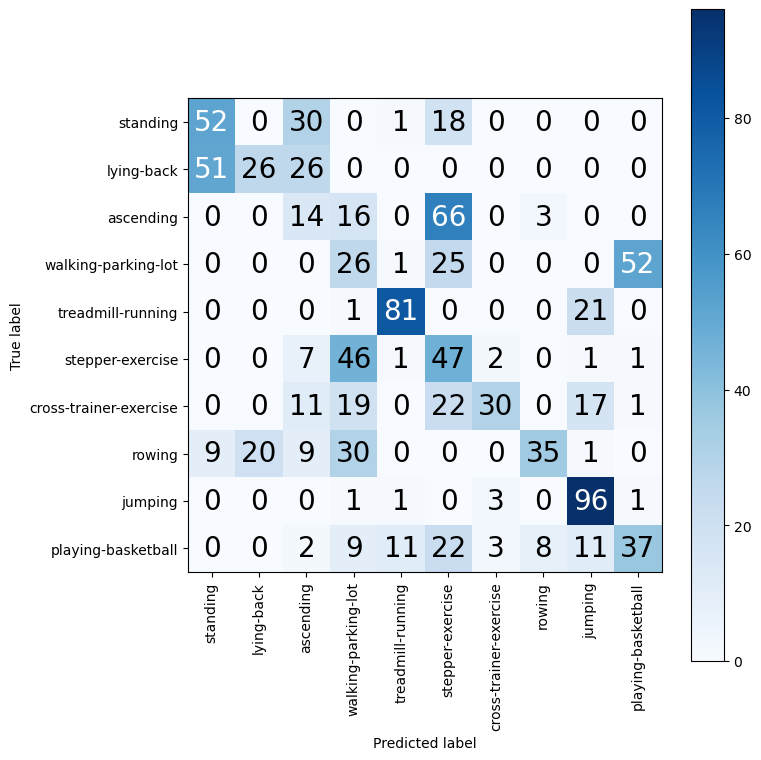

Epoch: 4
[288/3130 (9%)]	Loss: 1.287564	Class Loss: 0.591589	MMD Loss: 0.695976
[608/3130 (20%)]	Loss: 1.356116	Class Loss: 0.490534	MMD Loss: 0.865582
[928/3130 (30%)]	Loss: 1.436307	Class Loss: 0.786070	MMD Loss: 0.650237
[1248/3130 (40%)]	Loss: 1.383639	Class Loss: 0.714235	MMD Loss: 0.669403
[1568/3130 (51%)]	Loss: 1.095884	Class Loss: 0.459737	MMD Loss: 0.636147
[1888/3130 (61%)]	Loss: 1.353780	Class Loss: 0.686882	MMD Loss: 0.666898
[2208/3130 (71%)]	Loss: 1.499134	Class Loss: 0.862738	MMD Loss: 0.636396
[2528/3130 (81%)]	Loss: 1.451945	Class Loss: 0.792343	MMD Loss: 0.659602
[2848/3130 (92%)]	Loss: 1.268921	Class Loss: 0.581700	MMD Loss: 0.687221

Source Accuracy: 2993/4171 (71.7574%)
Target Accuracy: 492/1042 (47.2169%)
Target micro-f1: 0.48046875


<Figure size 2000x2000 with 0 Axes>

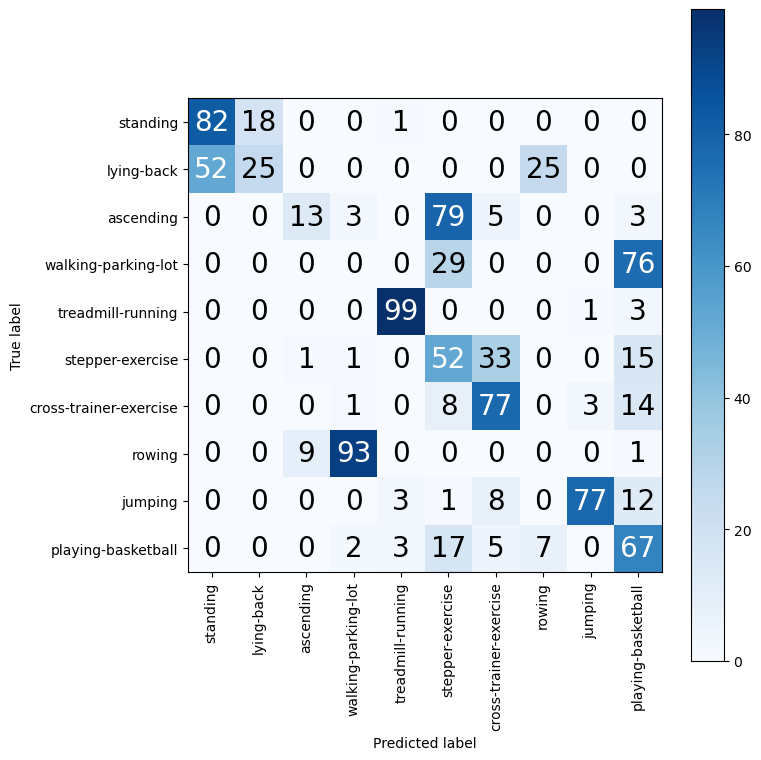

Epoch: 5
[288/3130 (9%)]	Loss: 1.443153	Class Loss: 0.722088	MMD Loss: 0.721065
[608/3130 (20%)]	Loss: 1.291846	Class Loss: 0.721742	MMD Loss: 0.570104
[928/3130 (30%)]	Loss: 1.204883	Class Loss: 0.599044	MMD Loss: 0.605839
[1248/3130 (40%)]	Loss: 1.292974	Class Loss: 0.696981	MMD Loss: 0.595993
[1568/3130 (51%)]	Loss: 1.400510	Class Loss: 0.625806	MMD Loss: 0.774704
[1888/3130 (61%)]	Loss: 1.240860	Class Loss: 0.570351	MMD Loss: 0.670509
[2208/3130 (71%)]	Loss: 1.234360	Class Loss: 0.645260	MMD Loss: 0.589100
[2528/3130 (81%)]	Loss: 1.280844	Class Loss: 0.515397	MMD Loss: 0.765447
[2848/3130 (92%)]	Loss: 1.193715	Class Loss: 0.585000	MMD Loss: 0.608714

Source Accuracy: 3324/4171 (79.6931%)
Target Accuracy: 493/1042 (47.3129%)
Target micro-f1: 0.4814453125


<Figure size 2000x2000 with 0 Axes>

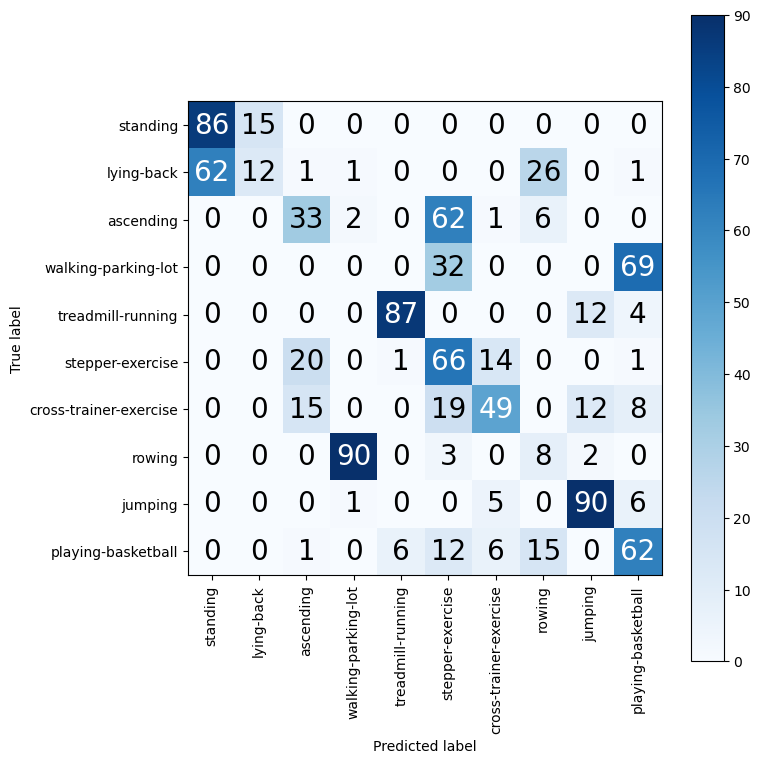

Epoch: 6
[288/3130 (9%)]	Loss: 1.102779	Class Loss: 0.464794	MMD Loss: 0.637985
[608/3130 (20%)]	Loss: 1.141048	Class Loss: 0.401012	MMD Loss: 0.740036
[928/3130 (30%)]	Loss: 1.447182	Class Loss: 0.579987	MMD Loss: 0.867196
[1248/3130 (40%)]	Loss: 1.171282	Class Loss: 0.466407	MMD Loss: 0.704875
[1568/3130 (51%)]	Loss: 1.393189	Class Loss: 0.753858	MMD Loss: 0.639331
[1888/3130 (61%)]	Loss: 1.134276	Class Loss: 0.514931	MMD Loss: 0.619345
[2208/3130 (71%)]	Loss: 1.316329	Class Loss: 0.550777	MMD Loss: 0.765552
[2528/3130 (81%)]	Loss: 1.301023	Class Loss: 0.621386	MMD Loss: 0.679637
[2848/3130 (92%)]	Loss: 1.482479	Class Loss: 0.822045	MMD Loss: 0.660433

Source Accuracy: 3432/4171 (82.2824%)
Target Accuracy: 563/1042 (54.0307%)
Target micro-f1: 0.5498046875


<Figure size 2000x2000 with 0 Axes>

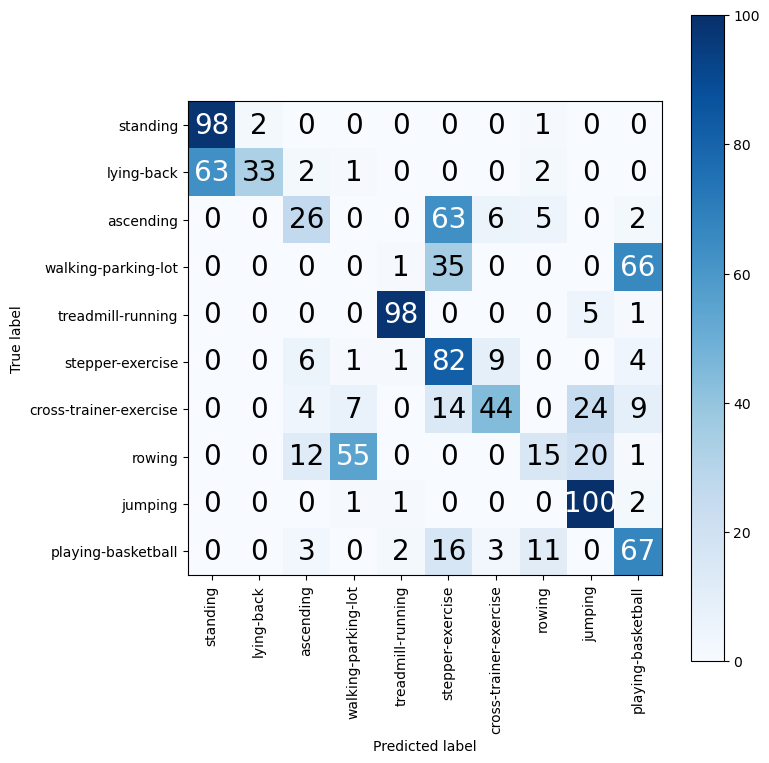

Epoch: 7
[288/3130 (9%)]	Loss: 1.049298	Class Loss: 0.476720	MMD Loss: 0.572577
[608/3130 (20%)]	Loss: 1.335087	Class Loss: 0.576085	MMD Loss: 0.759001
[928/3130 (30%)]	Loss: 1.053715	Class Loss: 0.280301	MMD Loss: 0.773414
[1248/3130 (40%)]	Loss: 0.939901	Class Loss: 0.329409	MMD Loss: 0.610493
[1568/3130 (51%)]	Loss: 0.984147	Class Loss: 0.347351	MMD Loss: 0.636797
[1888/3130 (61%)]	Loss: 0.854950	Class Loss: 0.251076	MMD Loss: 0.603874
[2208/3130 (71%)]	Loss: 1.047755	Class Loss: 0.359925	MMD Loss: 0.687831
[2528/3130 (81%)]	Loss: 0.907696	Class Loss: 0.309223	MMD Loss: 0.598474
[2848/3130 (92%)]	Loss: 1.090294	Class Loss: 0.440695	MMD Loss: 0.649599

Source Accuracy: 3478/4171 (83.3853%)
Target Accuracy: 490/1042 (47.0250%)
Target micro-f1: 0.478515625


<Figure size 2000x2000 with 0 Axes>

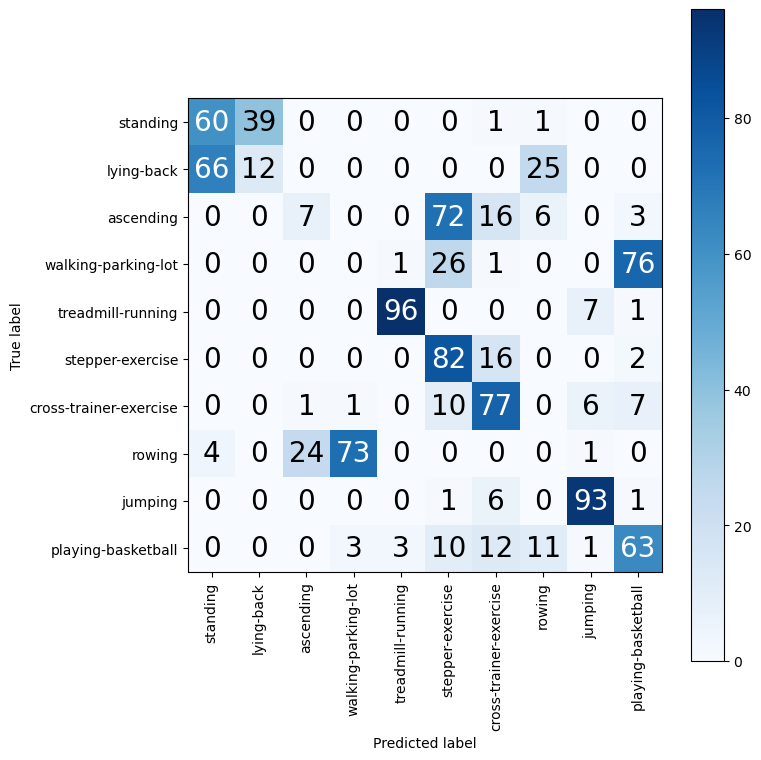

Epoch: 8
[288/3130 (9%)]	Loss: 1.016280	Class Loss: 0.419632	MMD Loss: 0.596648
[608/3130 (20%)]	Loss: 1.310741	Class Loss: 0.724088	MMD Loss: 0.586653
[928/3130 (30%)]	Loss: 1.052221	Class Loss: 0.393025	MMD Loss: 0.659195
[1248/3130 (40%)]	Loss: 0.856164	Class Loss: 0.240151	MMD Loss: 0.616014
[1568/3130 (51%)]	Loss: 0.939258	Class Loss: 0.295145	MMD Loss: 0.644113
[1888/3130 (61%)]	Loss: 1.018739	Class Loss: 0.379594	MMD Loss: 0.639144
[2208/3130 (71%)]	Loss: 1.222908	Class Loss: 0.505786	MMD Loss: 0.717122
[2528/3130 (81%)]	Loss: 1.227316	Class Loss: 0.561787	MMD Loss: 0.665529
[2848/3130 (92%)]	Loss: 1.262762	Class Loss: 0.592790	MMD Loss: 0.669972

Source Accuracy: 3656/4171 (87.6528%)
Target Accuracy: 571/1042 (54.7985%)
Target micro-f1: 0.5576171875


<Figure size 2000x2000 with 0 Axes>

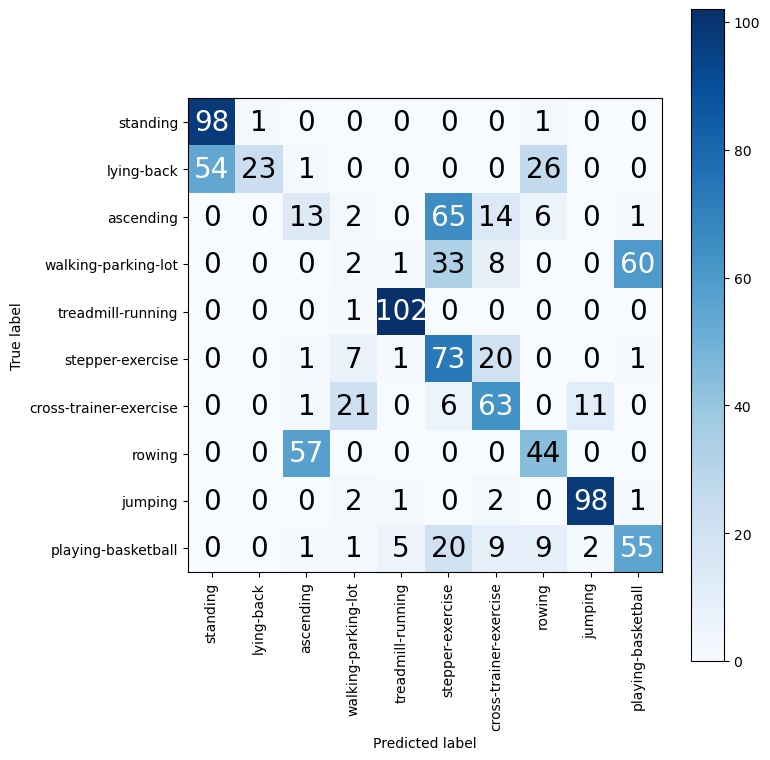

Epoch: 9
[288/3130 (9%)]	Loss: 0.940732	Class Loss: 0.345578	MMD Loss: 0.595155
[608/3130 (20%)]	Loss: 0.841488	Class Loss: 0.179611	MMD Loss: 0.661877
[928/3130 (30%)]	Loss: 1.021505	Class Loss: 0.341091	MMD Loss: 0.680414
[1248/3130 (40%)]	Loss: 0.938117	Class Loss: 0.300490	MMD Loss: 0.637627
[1568/3130 (51%)]	Loss: 0.861872	Class Loss: 0.128257	MMD Loss: 0.733616
[1888/3130 (61%)]	Loss: 0.844259	Class Loss: 0.176624	MMD Loss: 0.667635
[2208/3130 (71%)]	Loss: 1.008899	Class Loss: 0.332076	MMD Loss: 0.676824
[2528/3130 (81%)]	Loss: 0.892289	Class Loss: 0.267851	MMD Loss: 0.624438
[2848/3130 (92%)]	Loss: 0.922658	Class Loss: 0.317867	MMD Loss: 0.604790

Source Accuracy: 3708/4171 (88.8995%)
Target Accuracy: 514/1042 (49.3282%)
Target micro-f1: 0.501953125


<Figure size 2000x2000 with 0 Axes>

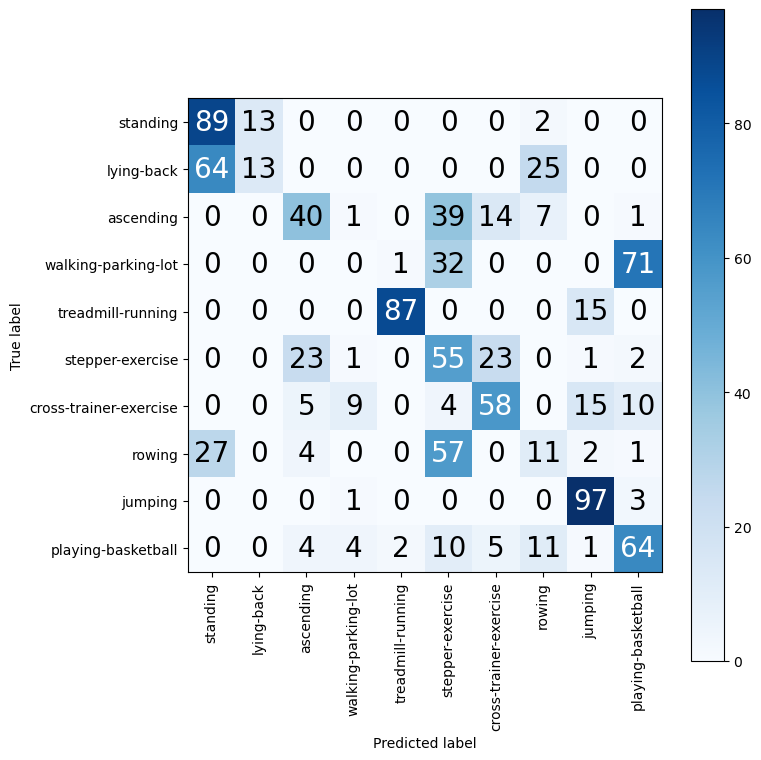

Epoch: 10
[288/3130 (9%)]	Loss: 1.002625	Class Loss: 0.294277	MMD Loss: 0.708348
[608/3130 (20%)]	Loss: 1.018417	Class Loss: 0.358540	MMD Loss: 0.659876
[928/3130 (30%)]	Loss: 0.761058	Class Loss: 0.167557	MMD Loss: 0.593502
[1248/3130 (40%)]	Loss: 1.033899	Class Loss: 0.392002	MMD Loss: 0.641897
[1568/3130 (51%)]	Loss: 1.196707	Class Loss: 0.536149	MMD Loss: 0.660558
[1888/3130 (61%)]	Loss: 0.856553	Class Loss: 0.219971	MMD Loss: 0.636582
[2208/3130 (71%)]	Loss: 1.156225	Class Loss: 0.506265	MMD Loss: 0.649960
[2528/3130 (81%)]	Loss: 0.877296	Class Loss: 0.228080	MMD Loss: 0.649217
[2848/3130 (92%)]	Loss: 1.090155	Class Loss: 0.433036	MMD Loss: 0.657120

Source Accuracy: 3695/4171 (88.5879%)
Target Accuracy: 547/1042 (52.4952%)
Target micro-f1: 0.5341796875


<Figure size 2000x2000 with 0 Axes>

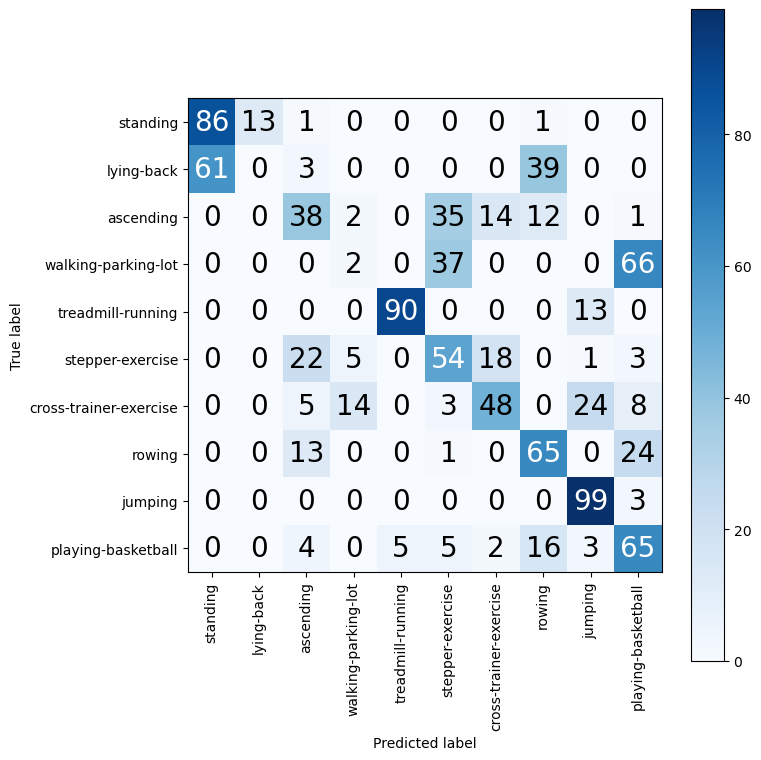

Epoch: 11
[288/3130 (9%)]	Loss: 0.850534	Class Loss: 0.229689	MMD Loss: 0.620845
[608/3130 (20%)]	Loss: 0.718851	Class Loss: 0.099986	MMD Loss: 0.618864
[928/3130 (30%)]	Loss: 0.923146	Class Loss: 0.328785	MMD Loss: 0.594361
[1248/3130 (40%)]	Loss: 0.889989	Class Loss: 0.171659	MMD Loss: 0.718329
[1568/3130 (51%)]	Loss: 0.929563	Class Loss: 0.302320	MMD Loss: 0.627243
[1888/3130 (61%)]	Loss: 0.934612	Class Loss: 0.223624	MMD Loss: 0.710988
[2208/3130 (71%)]	Loss: 0.785528	Class Loss: 0.182083	MMD Loss: 0.603445
[2528/3130 (81%)]	Loss: 0.853652	Class Loss: 0.165575	MMD Loss: 0.688077
[2848/3130 (92%)]	Loss: 0.935498	Class Loss: 0.313426	MMD Loss: 0.622071

Source Accuracy: 3754/4171 (90.0024%)
Target Accuracy: 533/1042 (51.1516%)
Target micro-f1: 0.5205078125


<Figure size 2000x2000 with 0 Axes>

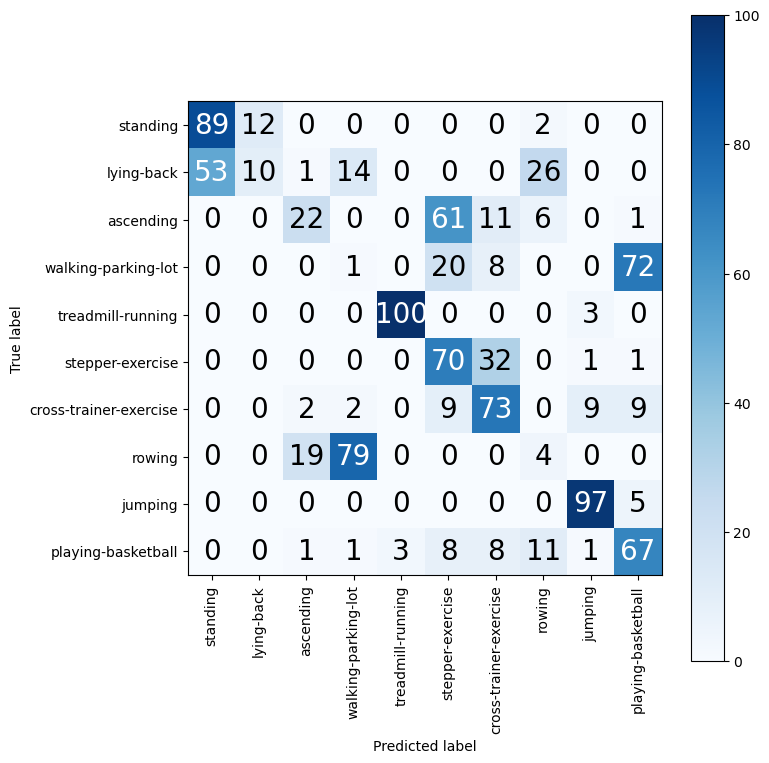

Epoch: 12
[288/3130 (9%)]	Loss: 0.932970	Class Loss: 0.235696	MMD Loss: 0.697274
[608/3130 (20%)]	Loss: 0.883608	Class Loss: 0.212810	MMD Loss: 0.670798
[928/3130 (30%)]	Loss: 0.856620	Class Loss: 0.219743	MMD Loss: 0.636876
[1248/3130 (40%)]	Loss: 0.961602	Class Loss: 0.298347	MMD Loss: 0.663254
[1568/3130 (51%)]	Loss: 0.937881	Class Loss: 0.215674	MMD Loss: 0.722207
[1888/3130 (61%)]	Loss: 0.831264	Class Loss: 0.177449	MMD Loss: 0.653815
[2208/3130 (71%)]	Loss: 0.758503	Class Loss: 0.109769	MMD Loss: 0.648735
[2528/3130 (81%)]	Loss: 0.769918	Class Loss: 0.149935	MMD Loss: 0.619983
[2848/3130 (92%)]	Loss: 0.841503	Class Loss: 0.111031	MMD Loss: 0.730472

Source Accuracy: 3837/4171 (91.9923%)
Target Accuracy: 585/1042 (56.1420%)
Target micro-f1: 0.5712890625


<Figure size 2000x2000 with 0 Axes>

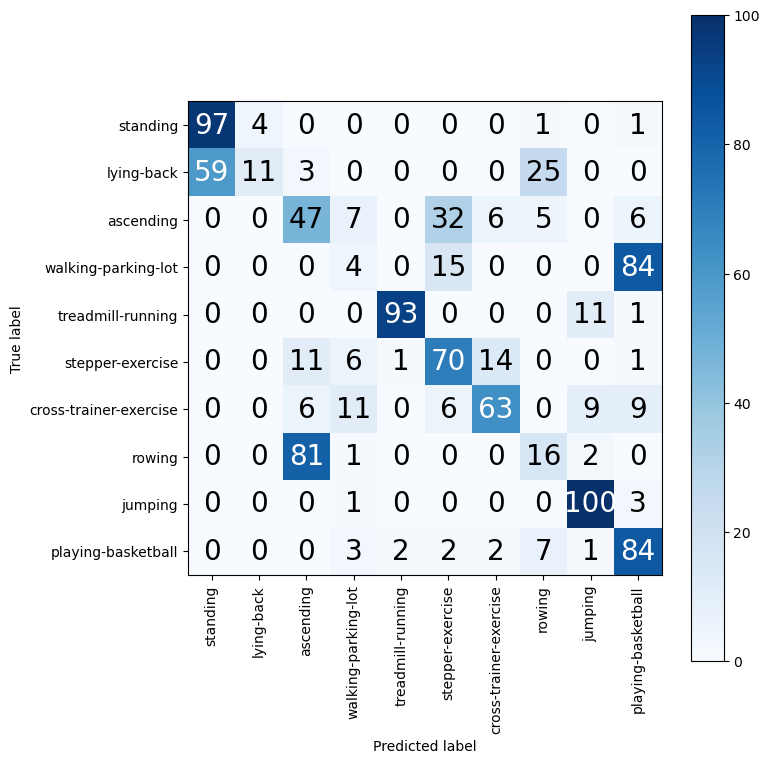

Epoch: 13
[288/3130 (9%)]	Loss: 0.727114	Class Loss: 0.085722	MMD Loss: 0.641392
[608/3130 (20%)]	Loss: 0.799530	Class Loss: 0.076466	MMD Loss: 0.723063
[928/3130 (30%)]	Loss: 0.869166	Class Loss: 0.233012	MMD Loss: 0.636154
[1248/3130 (40%)]	Loss: 0.749937	Class Loss: 0.117436	MMD Loss: 0.632501
[1568/3130 (51%)]	Loss: 0.799523	Class Loss: 0.192657	MMD Loss: 0.606867
[1888/3130 (61%)]	Loss: 0.830741	Class Loss: 0.171350	MMD Loss: 0.659390
[2208/3130 (71%)]	Loss: 0.706619	Class Loss: 0.116341	MMD Loss: 0.590278
[2528/3130 (81%)]	Loss: 1.094341	Class Loss: 0.464386	MMD Loss: 0.629955
[2848/3130 (92%)]	Loss: 0.926681	Class Loss: 0.290899	MMD Loss: 0.635782

Source Accuracy: 3879/4171 (92.9993%)
Target Accuracy: 630/1042 (60.4607%)
Target micro-f1: 0.615234375


<Figure size 2000x2000 with 0 Axes>

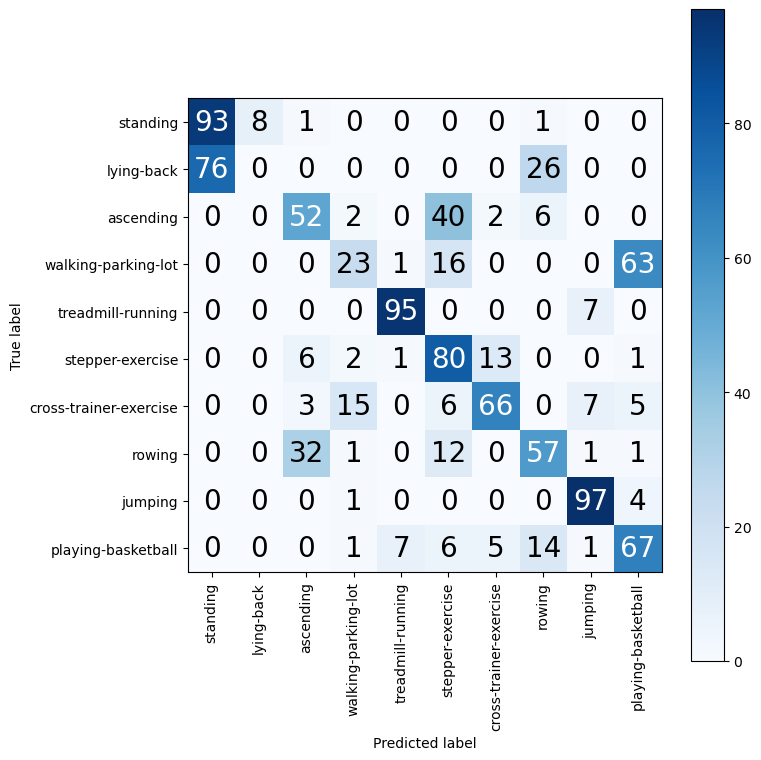

Epoch: 14
[288/3130 (9%)]	Loss: 0.796464	Class Loss: 0.154890	MMD Loss: 0.641573
[608/3130 (20%)]	Loss: 0.724620	Class Loss: 0.118846	MMD Loss: 0.605775
[928/3130 (30%)]	Loss: 0.763737	Class Loss: 0.116544	MMD Loss: 0.647193
[1248/3130 (40%)]	Loss: 0.683699	Class Loss: 0.087581	MMD Loss: 0.596118
[1568/3130 (51%)]	Loss: 0.799379	Class Loss: 0.163353	MMD Loss: 0.636027
[1888/3130 (61%)]	Loss: 0.762529	Class Loss: 0.115784	MMD Loss: 0.646744
[2208/3130 (71%)]	Loss: 0.824995	Class Loss: 0.213756	MMD Loss: 0.611239
[2528/3130 (81%)]	Loss: 0.784496	Class Loss: 0.161386	MMD Loss: 0.623110
[2848/3130 (92%)]	Loss: 0.778937	Class Loss: 0.195944	MMD Loss: 0.582994

Source Accuracy: 3859/4171 (92.5198%)
Target Accuracy: 650/1042 (62.3800%)
Target micro-f1: 0.634765625


<Figure size 2000x2000 with 0 Axes>

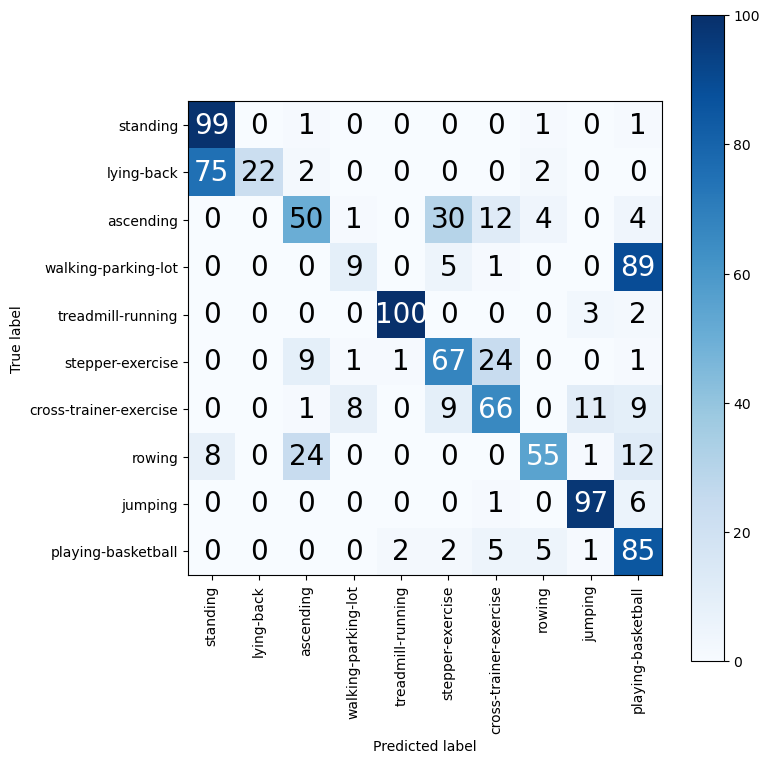

Epoch: 15
[288/3130 (9%)]	Loss: 0.726253	Class Loss: 0.100631	MMD Loss: 0.625622
[608/3130 (20%)]	Loss: 0.806318	Class Loss: 0.172928	MMD Loss: 0.633390
[928/3130 (30%)]	Loss: 0.761603	Class Loss: 0.094284	MMD Loss: 0.667319
[1248/3130 (40%)]	Loss: 0.919915	Class Loss: 0.288645	MMD Loss: 0.631270
[1568/3130 (51%)]	Loss: 0.940549	Class Loss: 0.234729	MMD Loss: 0.705820
[1888/3130 (61%)]	Loss: 0.836163	Class Loss: 0.150346	MMD Loss: 0.685818
[2208/3130 (71%)]	Loss: 0.829824	Class Loss: 0.118489	MMD Loss: 0.711335
[2528/3130 (81%)]	Loss: 0.701887	Class Loss: 0.097136	MMD Loss: 0.604751
[2848/3130 (92%)]	Loss: 0.839423	Class Loss: 0.238750	MMD Loss: 0.600673

Source Accuracy: 3888/4171 (93.2151%)
Target Accuracy: 636/1042 (61.0365%)
Target micro-f1: 0.62109375


<Figure size 2000x2000 with 0 Axes>

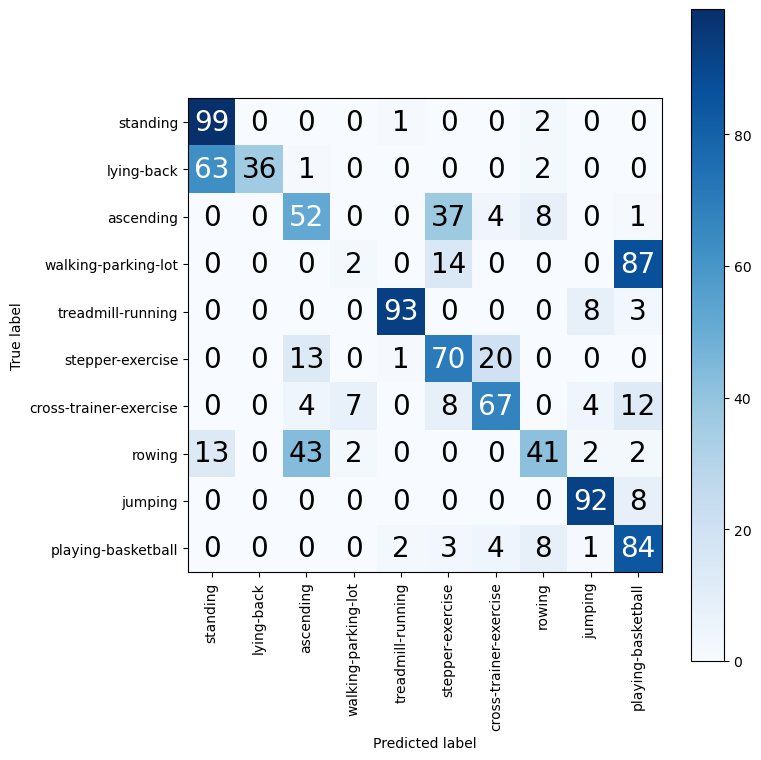

Epoch: 16
[288/3130 (9%)]	Loss: 0.758137	Class Loss: 0.092279	MMD Loss: 0.665858
[608/3130 (20%)]	Loss: 0.905551	Class Loss: 0.266076	MMD Loss: 0.639475
[928/3130 (30%)]	Loss: 0.787531	Class Loss: 0.119527	MMD Loss: 0.668004
[1248/3130 (40%)]	Loss: 1.017049	Class Loss: 0.278007	MMD Loss: 0.739042
[1568/3130 (51%)]	Loss: 1.263209	Class Loss: 0.644601	MMD Loss: 0.618608
[1888/3130 (61%)]	Loss: 0.761722	Class Loss: 0.121944	MMD Loss: 0.639778
[2208/3130 (71%)]	Loss: 0.750616	Class Loss: 0.085246	MMD Loss: 0.665370
[2528/3130 (81%)]	Loss: 0.860207	Class Loss: 0.219720	MMD Loss: 0.640488
[2848/3130 (92%)]	Loss: 0.797319	Class Loss: 0.177722	MMD Loss: 0.619596

Source Accuracy: 3925/4171 (94.1021%)
Target Accuracy: 683/1042 (65.5470%)
Target micro-f1: 0.6669921875


<Figure size 2000x2000 with 0 Axes>

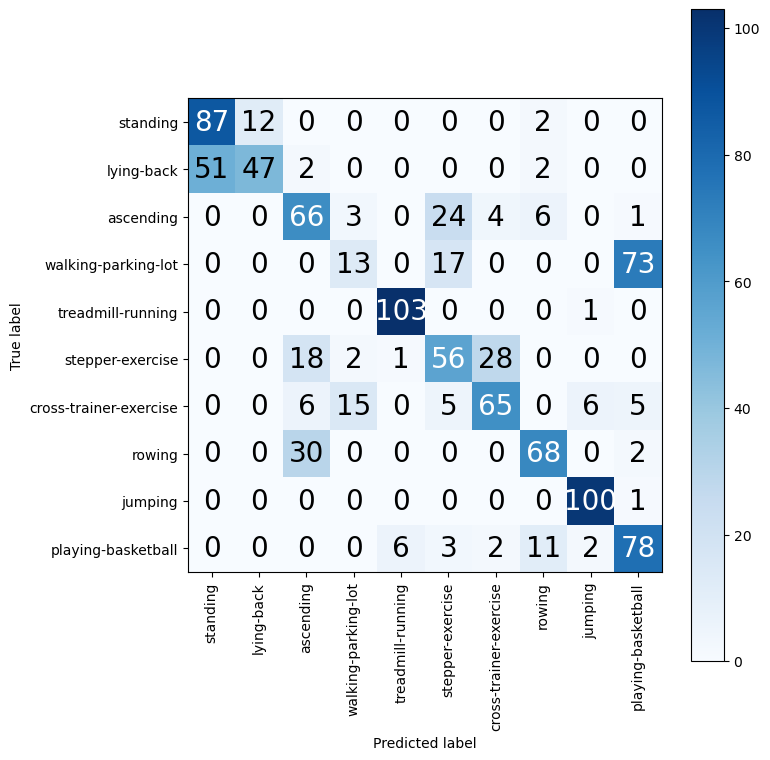

Epoch: 17
[288/3130 (9%)]	Loss: 0.655093	Class Loss: 0.058400	MMD Loss: 0.596693
[608/3130 (20%)]	Loss: 0.857765	Class Loss: 0.221864	MMD Loss: 0.635901
[928/3130 (30%)]	Loss: 0.710516	Class Loss: 0.110274	MMD Loss: 0.600242
[1248/3130 (40%)]	Loss: 0.849573	Class Loss: 0.181450	MMD Loss: 0.668123
[1568/3130 (51%)]	Loss: 0.833893	Class Loss: 0.174795	MMD Loss: 0.659098
[1888/3130 (61%)]	Loss: 0.965780	Class Loss: 0.310130	MMD Loss: 0.655650
[2208/3130 (71%)]	Loss: 0.730290	Class Loss: 0.128830	MMD Loss: 0.601460
[2528/3130 (81%)]	Loss: 0.686116	Class Loss: 0.078703	MMD Loss: 0.607413
[2848/3130 (92%)]	Loss: 0.684435	Class Loss: 0.064202	MMD Loss: 0.620233

Source Accuracy: 3920/4171 (93.9823%)
Target Accuracy: 665/1042 (63.8196%)
Target micro-f1: 0.6494140625


<Figure size 2000x2000 with 0 Axes>

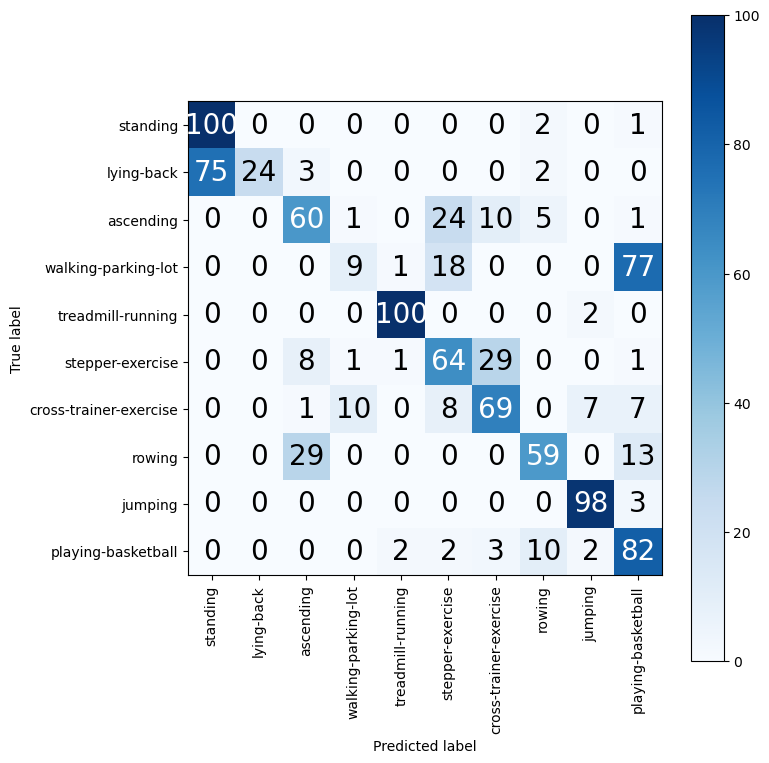

Epoch: 18
[288/3130 (9%)]	Loss: 0.751891	Class Loss: 0.096864	MMD Loss: 0.655027
[608/3130 (20%)]	Loss: 0.786961	Class Loss: 0.179073	MMD Loss: 0.607887
[928/3130 (30%)]	Loss: 0.810042	Class Loss: 0.133312	MMD Loss: 0.676731
[1248/3130 (40%)]	Loss: 0.701130	Class Loss: 0.076967	MMD Loss: 0.624163
[1568/3130 (51%)]	Loss: 0.797243	Class Loss: 0.150389	MMD Loss: 0.646854
[1888/3130 (61%)]	Loss: 0.912612	Class Loss: 0.231327	MMD Loss: 0.681284
[2208/3130 (71%)]	Loss: 0.702076	Class Loss: 0.070185	MMD Loss: 0.631890
[2528/3130 (81%)]	Loss: 0.709453	Class Loss: 0.066399	MMD Loss: 0.643054
[2848/3130 (92%)]	Loss: 0.891004	Class Loss: 0.243201	MMD Loss: 0.647803

Source Accuracy: 3878/4171 (92.9753%)
Target Accuracy: 660/1042 (63.3397%)
Target micro-f1: 0.64453125


<Figure size 2000x2000 with 0 Axes>

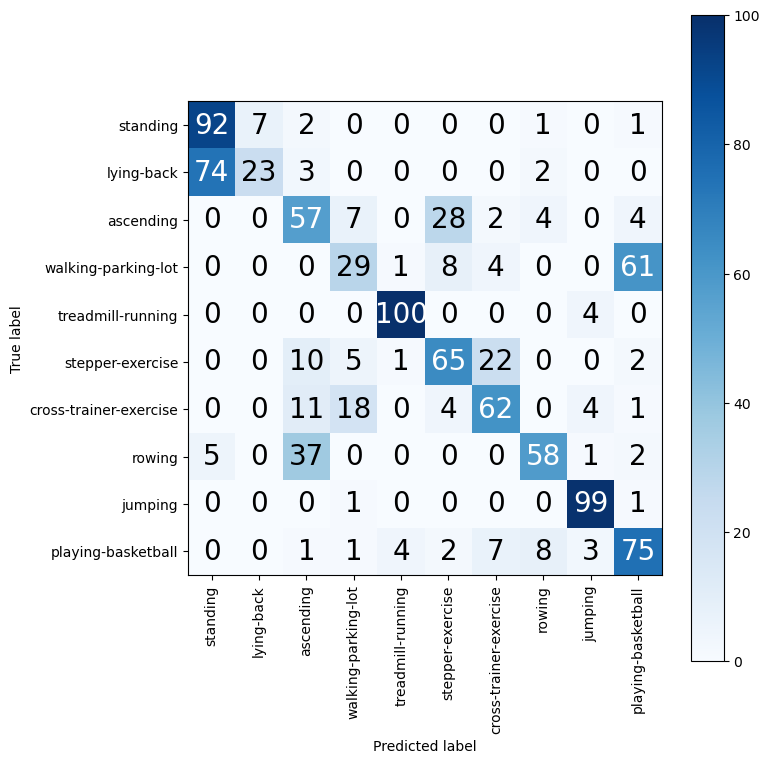

Epoch: 19
[288/3130 (9%)]	Loss: 0.827199	Class Loss: 0.254312	MMD Loss: 0.572887
[608/3130 (20%)]	Loss: 0.689359	Class Loss: 0.053540	MMD Loss: 0.635819
[928/3130 (30%)]	Loss: 0.689021	Class Loss: 0.074194	MMD Loss: 0.614827
[1248/3130 (40%)]	Loss: 0.705765	Class Loss: 0.062387	MMD Loss: 0.643377
[1568/3130 (51%)]	Loss: 0.660851	Class Loss: 0.062897	MMD Loss: 0.597954
[1888/3130 (61%)]	Loss: 0.930775	Class Loss: 0.307626	MMD Loss: 0.623149
[2208/3130 (71%)]	Loss: 0.676940	Class Loss: 0.047408	MMD Loss: 0.629531
[2528/3130 (81%)]	Loss: 0.828088	Class Loss: 0.169711	MMD Loss: 0.658377
[2848/3130 (92%)]	Loss: 0.803884	Class Loss: 0.133710	MMD Loss: 0.670173

Source Accuracy: 3862/4171 (92.5917%)
Target Accuracy: 609/1042 (58.4453%)
Target micro-f1: 0.5947265625


<Figure size 2000x2000 with 0 Axes>

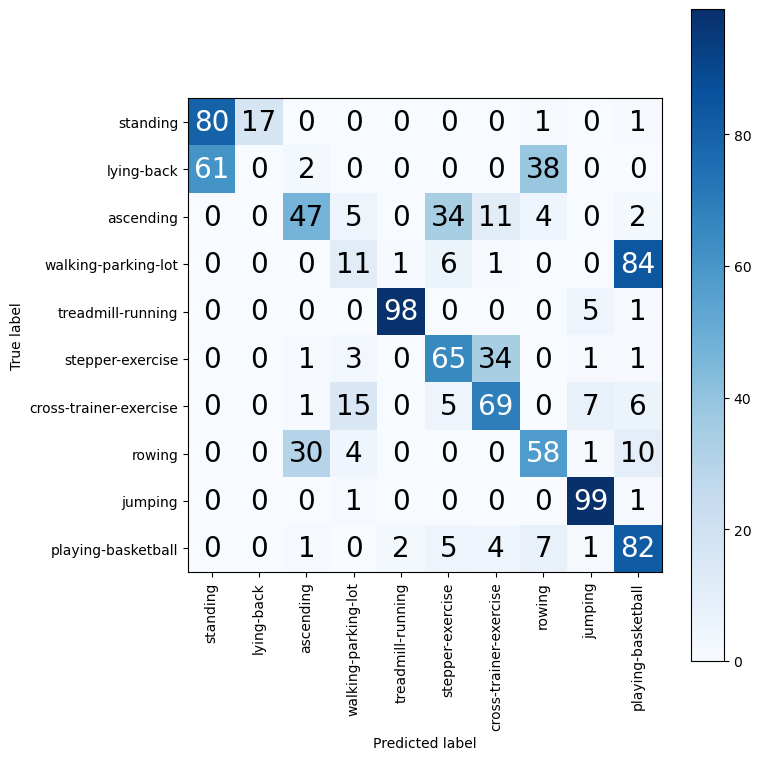

Epoch: 20
[288/3130 (9%)]	Loss: 0.635892	Class Loss: 0.034448	MMD Loss: 0.601444
[608/3130 (20%)]	Loss: 0.769632	Class Loss: 0.099630	MMD Loss: 0.670002
[928/3130 (30%)]	Loss: 0.793864	Class Loss: 0.135425	MMD Loss: 0.658440
[1248/3130 (40%)]	Loss: 0.742541	Class Loss: 0.134454	MMD Loss: 0.608087
[1568/3130 (51%)]	Loss: 0.707767	Class Loss: 0.096516	MMD Loss: 0.611250
[1888/3130 (61%)]	Loss: 0.763417	Class Loss: 0.116075	MMD Loss: 0.647342
[2208/3130 (71%)]	Loss: 0.772451	Class Loss: 0.121574	MMD Loss: 0.650878
[2528/3130 (81%)]	Loss: 0.725253	Class Loss: 0.063592	MMD Loss: 0.661661
[2848/3130 (92%)]	Loss: 0.844576	Class Loss: 0.190544	MMD Loss: 0.654032

Source Accuracy: 3977/4171 (95.3488%)
Target Accuracy: 664/1042 (63.7236%)
Target micro-f1: 0.6484375


<Figure size 2000x2000 with 0 Axes>

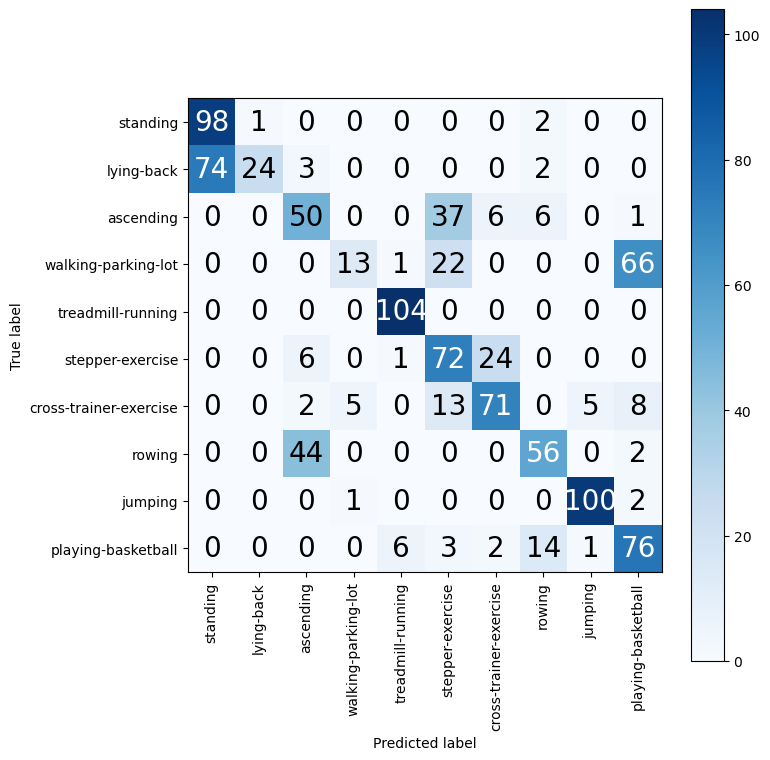

Source Domain accuracy: 95.34883880615234
Target Domain accuracy: 63.723609924316406
[INFO] Object saved to /media/soham/CorsairSSD/Research/Dr.AvijoyChakma/Project/DAN/Output/DSADS-Cross-Position-Heterogeneity/10_Activity_Window_128_Overlap_0.1/Target-Position-LL/seed0/training_stats.yaml
[INFO] Object saved to /media/soham/CorsairSSD/Research/Dr.AvijoyChakma/Project/DAN/Output/DSADS-Cross-Position-Heterogeneity/10_Activity_Window_128_Overlap_0.1/Target-Position-LL/seed0/testing_stats.yaml


In [119]:
common_net = Extractor().to(DEVICE)
src_net = Classifier(len(activities)).to(DEVICE)
tgt_net = Classifier(len(activities)).to(DEVICE)

train_hist = {}
train_hist['Total_loss'] = []
train_hist['Class_loss'] = []
train_hist['MMD_loss'] = []

test_hist = {}
test_hist['Source Accuracy'] = []
test_hist['Target Accuracy'] = []
test_hist['Micro-F1'] = []

optimizer = optim.SGD([{'params': common_net.parameters()},
                       {'params': src_net.parameters()},
                       {'params': tgt_net.parameters()}], lr=LEARNING_RATE, momentum=MOMENTUM)

criterion = nn.CrossEntropyLoss()

for epoch in range(EPOCHS):
    print('Epoch: {}'.format(epoch+1))
    train(common_net, src_net, tgt_net, optimizer, criterion,
                epoch, S_train, T_train, DEVICE, train_hist)
    test(common_net, src_net, S_valid, T_valid, epoch, DEVICE, test_hist)
    
    torch.save(common_net.state_dict(), save_path + 'common_net.pth')
    torch.save(src_net.state_dict(), save_path + 'source_net.pth')
    torch.save(tgt_net.state_dict(), save_path + 'target_net.pth')

    
print(f"Source Domain accuracy: {test_hist['Source Accuracy'][-1]}")
print(f"Target Domain accuracy: {test_hist['Target Accuracy'][-1]}")
    
# Save the results
with open(save_path+"training_stats.yaml", 'w', encoding='utf-8') as f:
    yaml.dump(train_hist, f, allow_unicode=True)
    print('[INFO] Object saved to {}'.format(save_path + "training_stats.yaml"))

with open(save_path+"testing_stats.yaml", 'w', encoding='utf-8') as f:
    yaml.dump(test_hist, f, allow_unicode=True)
    print('[INFO] Object saved to {}'.format(save_path + "testing_stats.yaml"))